 [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) datasets which is sub-dataset of CIFAR-100 Dataset. The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. <br>

Following are the classes in the dataset along with some random samples.

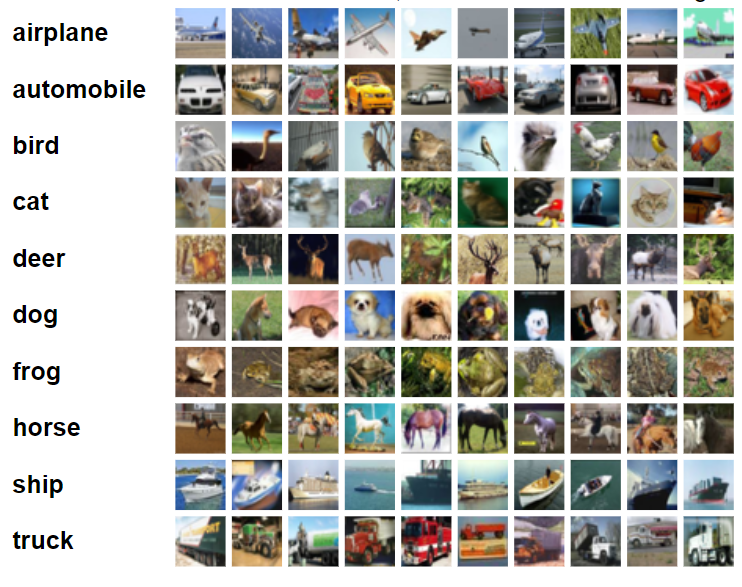

CIFAR-10 Classification:

In [1]:
# import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models,transforms
from torchvision.utils import make_grid
from torchvision.datasets import CIFAR10
from torch.utils.data.sampler import SubsetRandomSampler
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
# Data transforms (normalization & data augmentation)
# the values are the mean and standard deviation values of the color chanels of CIFAR10
# normalize pixel values by subtracting the mean and dividing by the standard deviation
normalize = transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])

# Data augmentation / preprocessing for training data
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # randomly crop images
    transforms.RandomHorizontalFlip(), # randomly flip images
    transforms.ToTensor(), # convert to tensor
    normalize # apply pixel normalization
])

# preprocessing test data
test_transform = transforms.Compose([ transforms.ToTensor(), normalize]) # convert to tensor and normalize

# Define batch size
batch_sz = 64

# Load CIFAR-10 dataset with defined transformations
train_dataset = CIFAR10(root='./datasets', train=True, download=True, transform=train_transform)
test_dataset = CIFAR10(root='./datasets', train=False, download=True, transform=test_transform)

# set dataloader
train_loader = DataLoader(train_dataset, batch_size=batch_sz, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_sz, shuffle=False)


100.0%
/usr/local/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## NN and CNN

In [3]:
# Define a 2 layer simple NN for cifar10 classificaiton
class NN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NN, self).__init__()
        self.hidden_layer = nn.Linear(input_size, hidden_size) # hidden layer
        self.dropout = nn.Dropout(dropout_prob) # dropout layer
        self.output_layer = nn.Linear(hidden_size, num_classes) # output layer
        self.relu = nn.ReLU() # ReLU activation functin

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input images
        x = self.relu(self.hidden_layer(x)) # ReLU activation
        x = self.dropout(x) # Apply dropout to the hidden layer output
        x = self.output_layer(x) # output layer
        return x # return final output

# Define the model parameters
input_size = 32 * 32 * 3 # 32pixel*32pixel*3channels
hidden_size = 500
num_classes = 10

# Dropout parameter
dropout_prob = 0.3

# Create model
model_NN = NN(input_size, hidden_size, num_classes)
print(model_NN)


NN(
  (hidden_layer): Linear(in_features=3072, out_features=500, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=500, out_features=10, bias=True)
  (relu): ReLU()
)


In [4]:
# Define a CNN with 2 conv layer and 2 linear layers for cifar10 classificaiton
class CNN(nn.Module):
    def __init__(self, num_classes, conv1_channels, conv2_channels, hidden_layer_1_output_size):
        super(CNN, self).__init__()
        # first conv layer
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=conv1_channels, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU() # ReLU activatoin function
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # max pooling, stride = stepsize

        # second conv layer
        self.conv2 = nn.Conv2d(in_channels=conv1_channels, out_channels=conv2_channels, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU() # ReLU activatoin function
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # max pooling

        # hidden layer
        self.hidden_layer_1 = nn.Linear(conv2_channels * 8 * 8, hidden_layer_1_output_size)
        self.dropout = nn.Dropout(dropout_prob) # dropout layer
        self.relu3 = nn.ReLU() # ReLU activatoin function

        # output layer
        self.output_layer = nn.Linear(hidden_layer_1_output_size, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x))) # apply conv1 with ReLU adn pooling
        x = self.pool2(self.relu2(self.conv2(x))) # apply conv2 with ReLU adn pooling
        x = x.view(x.size(0), -1)  # flatten tensor
        x = self.relu3(self.hidden_layer_1(x)) # apply relu to hidden layer
        x = self.dropout(x) # apply dropout to hidden layer
        x = self.output_layer(x) # output layer
        return x

# Parameters
conv1_channels = 64
conv2_channels = 128
hidden_layer_1_output_size = 256

# Create the model
model_CNN = CNN(num_classes, conv1_channels, conv2_channels, hidden_layer_1_output_size)
print(model_CNN)


CNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (hidden_layer_1): Linear(in_features=8192, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu3): ReLU()
  (output_layer): Linear(in_features=256, out_features=10, bias=True)
)


Training NeuralNetwork:
| Epoch [ 1/10] >> Train Loss: 1.8610 | Test Loss: 1.6606 | Train Accuracy: 38.98% | Test Accuracy: 41.48% | 
| Epoch [ 2/10] >> Train Loss: 1.7263 | Test Loss: 1.6071 | Train Accuracy: 41.75% | Test Accuracy: 43.76% | 
| Epoch [ 3/10] >> Train Loss: 1.6766 | Test Loss: 1.5895 | Train Accuracy: 43.52% | Test Accuracy: 44.66% | 
| Epoch [ 4/10] >> Train Loss: 1.6398 | Test Loss: 1.5510 | Train Accuracy: 45.42% | Test Accuracy: 45.34% | 
| Epoch [ 5/10] >> Train Loss: 1.6164 | Test Loss: 1.5459 | Train Accuracy: 45.47% | Test Accuracy: 45.95% | 
| Epoch [ 6/10] >> Train Loss: 1.5767 | Test Loss: 1.5101 | Train Accuracy: 46.89% | Test Accuracy: 46.78% | 
| Epoch [ 7/10] >> Train Loss: 1.5650 | Test Loss: 1.4943 | Train Accuracy: 47.37% | Test Accuracy: 47.62% | 
| Epoch [ 8/10] >> Train Loss: 1.5519 | Test Loss: 1.4986 | Train Accuracy: 47.61% | Test Accuracy: 47.02% | 
| Epoch [ 9/10] >> Train Loss: 1.5407 | Test Loss: 1.4809 | Train Accuracy: 48.43% | Test Accura

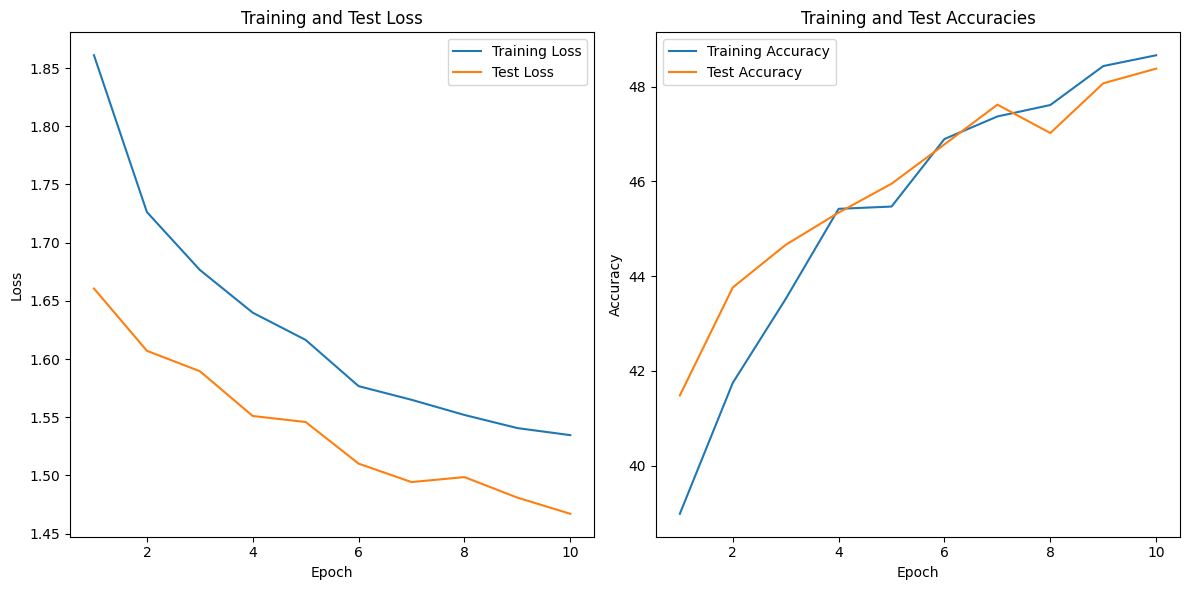

Training ConvolutionalNeuralNetwork:
| Epoch [ 1/10] >> Train Loss: 1.7656 | Test Loss: 1.4636 | Train Accuracy: 46.05% | Test Accuracy: 48.63% | 
| Epoch [ 2/10] >> Train Loss: 1.4945 | Test Loss: 1.3243 | Train Accuracy: 49.84% | Test Accuracy: 53.18% | 
| Epoch [ 3/10] >> Train Loss: 1.3913 | Test Loss: 1.2245 | Train Accuracy: 54.20% | Test Accuracy: 57.02% | 
| Epoch [ 4/10] >> Train Loss: 1.3074 | Test Loss: 1.1525 | Train Accuracy: 57.17% | Test Accuracy: 59.92% | 
| Epoch [ 5/10] >> Train Loss: 1.2393 | Test Loss: 1.0803 | Train Accuracy: 59.80% | Test Accuracy: 62.15% | 
| Epoch [ 6/10] >> Train Loss: 1.1752 | Test Loss: 1.0449 | Train Accuracy: 60.85% | Test Accuracy: 63.79% | 
| Epoch [ 7/10] >> Train Loss: 1.1467 | Test Loss: 1.0095 | Train Accuracy: 62.05% | Test Accuracy: 65.19% | 
| Epoch [ 8/10] >> Train Loss: 1.1236 | Test Loss: 0.9975 | Train Accuracy: 63.13% | Test Accuracy: 65.80% | 
| Epoch [ 9/10] >> Train Loss: 1.1074 | Test Loss: 0.9775 | Train Accuracy: 63.52% 

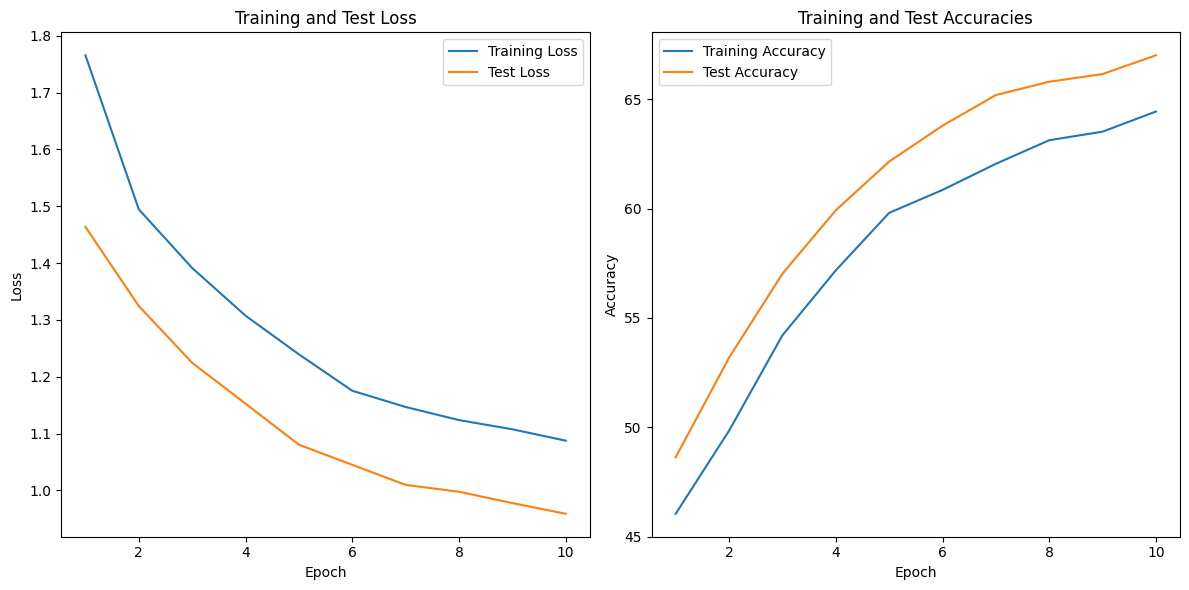

In [5]:
# Define the evaluate_model function
def evaluate_model(model, data_loader, criterion, device):
    model.eval() # set model to evaluation mode
    eval_loss = 0
    correct = 0
    total = 0

    # disable gradient calculation
    with torch.no_grad():
        for images, labels in data_loader:
            # move to gpu
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            outputs = model(images)

            # loss calculation
            loss = criterion(outputs, labels)
            eval_loss += loss.item()
            predicted = torch.max(outputs.data, 1)[1] # get predicted class labels
            total += labels.size(0) # total  number of samples
            correct += (predicted == labels).sum().item() # count correct predictions

    # calculate and return loss and accuracy
    test_accuracy = correct / total * 100
    return eval_loss / len(data_loader), test_accuracy

# Define the train_model function used by all models
def train_model(model, optimizer, scheduler, train_loader, test_loader, criterion, num_epochs):
    model.to(device)  # Move the model to gpu

    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train() # set model to training mode
        train_loss = 0

        # iterate over batches
        for images, labels in train_loader:
            # move to gpu
            images = images.to(device)
            labels = labels.to(device)

            # reset gradients
            optimizer.zero_grad()

            # forward pass
            outputs = model(images)

            # backpropagation
            loss = criterion(outputs, labels) # caclulate loss
            loss.backward() # compute gradients of the model with respect to the loss
            optimizer.step() # adjust model parameters
            train_loss += loss.item() # apply loss to total

        # calculate average test loss
        average_train_loss = train_loss / len(train_loader)
        train_losses.append(average_train_loss)

        # step the scheduler
        scheduler.step()

        # Calculate training accuracy
        train_accuracy = evaluate_model(model, train_loader, criterion, device)[1]
        train_accuracies.append(train_accuracy)

        # Calculate test loss and accuracy
        test_loss, test_accuracy = evaluate_model(model, test_loader, criterion, device)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        print(f"| Epoch [{epoch+1:2}/{num_epochs}] >> "
              f"Train Loss: {average_train_loss:.4f} | "
              f"Test Loss: {test_loss:.4f} | "
              f"Train Accuracy: {train_accuracy:.2f}% | "
              f"Test Accuracy: {test_accuracy:.2f}% | ")

    # Plot loss and accuracies
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs + 1), train_losses, label="Training Loss")
    plt.plot(range(1, num_epochs + 1), test_losses, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs + 1), train_accuracies, label="Training Accuracy")
    plt.plot(range(1, num_epochs + 1), test_accuracies, label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Test Accuracies")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Set up the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define loss function and optimizer
num_epochs = 10
learning_rate_NN = 0.00008
learning_rate_CNN = 0.00008

# optimizer, scheduler, L2 regularization, loss function
weight_decay = 1e-4 # so the weights stay small (L2 Regularization)
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer_NN = optim.Adam(model_NN.parameters(), lr=learning_rate_NN, weight_decay=weight_decay)
optimizer_CNN = optim.Adam(model_CNN.parameters(), lr=learning_rate_CNN, weight_decay=weight_decay)

# scheduler
scheduler_NN = optim.lr_scheduler.StepLR(optimizer_NN, step_size=5, gamma=0.5)
scheduler_CNN = optim.lr_scheduler.StepLR(optimizer_CNN, step_size=5, gamma=0.5)

# Move both models to gpu
model_NN.to(device)
model_CNN.to(device)

# Train NN
print("Training NeuralNetwork:\n============================================================================================================")
train_model(model_NN, optimizer_NN, scheduler_NN, train_loader, test_loader, criterion, num_epochs)

# Train CNN
print("Training ConvolutionalNeuralNetwork:\n============================================================================================================")
train_model(model_CNN, optimizer_CNN, scheduler_CNN, train_loader, test_loader, criterion, num_epochs)

NeuralNetwork:
 >> Loss (Training):     1.4671
 >> Accuracy (Training): 48.66%
 >> Loss (Testing):      1.4670
 >> Accuracy (Testing):  48.38%

ConvolutionalNeuralNetwork:
 >> Loss (Training):     1.0206
 >> Accuracy (Training): 64.17%
 >> Loss (Testing):      0.9587
 >> Accuracy (Testing):  67.01%


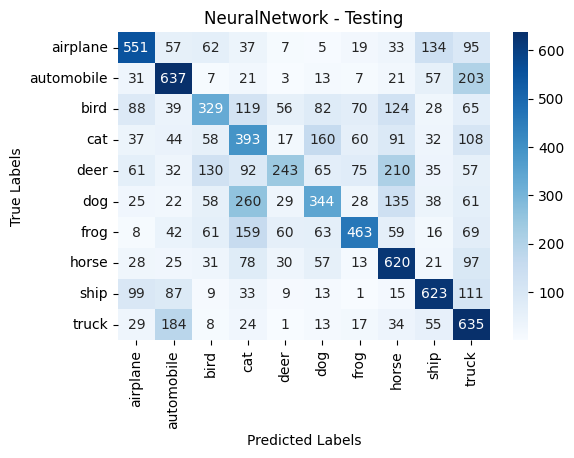

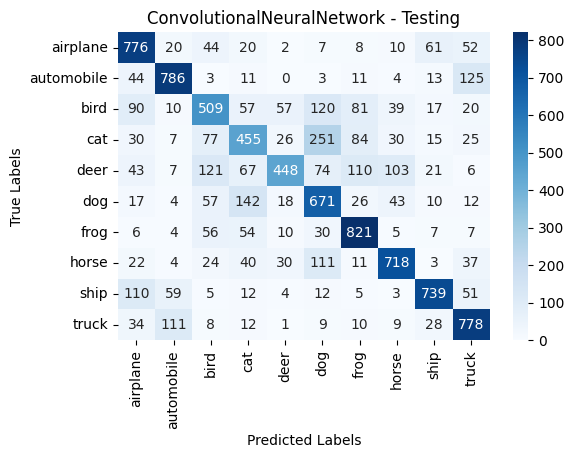

In [6]:
#Compare the accuarcay of both networks on the test set

# class names
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# Calculate performance
nn_train_loss, nn_train_accuracy = evaluate_model(model_NN, train_loader, criterion, device)
nn_test_loss, nn_test_accuracy = evaluate_model(model_NN, test_loader, criterion, device)

# Calculate performance
cnn_train_loss, cnn_train_accuracy = evaluate_model(model_CNN, train_loader, criterion, device)
cnn_test_loss, cnn_test_accuracy = evaluate_model(model_CNN, test_loader, criterion, device)

# Print NN
print("NeuralNetwork:")
print(f" >> Loss (Training):     {nn_train_loss:.4f}")
print(f" >> Accuracy (Training): {nn_train_accuracy:.2f}%")
print(f" >> Loss (Testing):      {nn_test_loss:.4f}")
print(f" >> Accuracy (Testing):  {nn_test_accuracy:.2f}%")

# Print CNN
print("\nConvolutionalNeuralNetwork:")
print(f" >> Loss (Training):     {cnn_train_loss:.4f}")
print(f" >> Accuracy (Training): {cnn_train_accuracy:.2f}%")
print(f" >> Loss (Testing):      {cnn_test_loss:.4f}")
print(f" >> Accuracy (Testing):  {cnn_test_accuracy:.2f}%")


# function to calculate confusion matrix
def calculate_confusion_matrix(model, data_loader, device):
    model.eval() # set model to evaluation mode
    all_predictions = []
    all_true_labels = []

    # disable gradient calculation
    with torch.no_grad():
        for images, labels in data_loader:
            # move to gpu
            images = images.to(device)
            labels =  labels.to(device)

            # forward pass
            outputs = model(images)
            predicted = torch.max(outputs, 1)[1] # get indices of predicted class labels
            all_predictions.extend(predicted.cpu().numpy()) # predicted labels
            all_true_labels.extend(labels.cpu().numpy()) # true labels

    # create and reutrn the CM
    confusion_matrix_data = confusion_matrix(all_true_labels, all_predictions)
    return confusion_matrix_data

# Calculate confusion matrices
nn_test_confusion_matrix = calculate_confusion_matrix(model_NN, test_loader, device)
cnn_test_confusion_matrix = calculate_confusion_matrix(model_CNN, test_loader, device)

# Plot CM for NN
plt.figure(figsize=(6, 4))
sns.heatmap(nn_test_confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("NeuralNetwork - Testing")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Plot CM for CNN
plt.figure(figsize=(6, 4))
sns.heatmap(cnn_test_confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("ConvolutionalNeuralNetwork - Testing")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()



/usr/local/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/vscode/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Training ResNet18:
| Epoch [ 1/10] >> Train Loss: 1.7208 | Test Loss: 1.1079 | Train Accuracy: 59.39% | Test Accuracy: 61.65% | 
| Epoch [ 2/10] >> Train Loss: 1.3722 | Test Loss: 1.1066 | Train Accuracy: 62.49% | Test Accuracy: 63.69% | 
| Epoch [ 3/10] >> Train Loss: 1.0791 | Test Loss: 0.8469 | Train Accuracy: 69.12% | Test Accuracy: 70.38% | 
| Epoch [ 4/10] >> Train Loss: 0.9274 | Test Loss: 0.9330 | Train Accuracy: 70.76% | Test Accuracy: 71.42% | 
| Epoch [ 5/10] >> Train Loss: 0.8231 | Test Loss: 0.8228 | Train Accuracy: 72.64% | Test Accuracy: 72.02% | 
| Epoch [ 6/10] >> Train Loss: 0.7343 | Test Loss: 0.7079 | Train Accuracy: 75.66% | Test Accuracy: 76.19% | 
| Epoch [ 7/10] >> Train Loss: 0.7407 | Test Loss: 0.6636 | Train Accuracy: 77.07% | Test Accuracy: 77.15% | 
| Epoch [ 8/10] >> Train Loss: 0.6731 | Test Loss: 0.6238 | Train Accuracy: 79.97% | Test Accuracy: 79.56% | 
| Epoch [ 9/10] >> Train Loss: 0.7117 | Test Loss: 0.7040 | Train Accuracy: 76.90% | Test Accuracy: 7

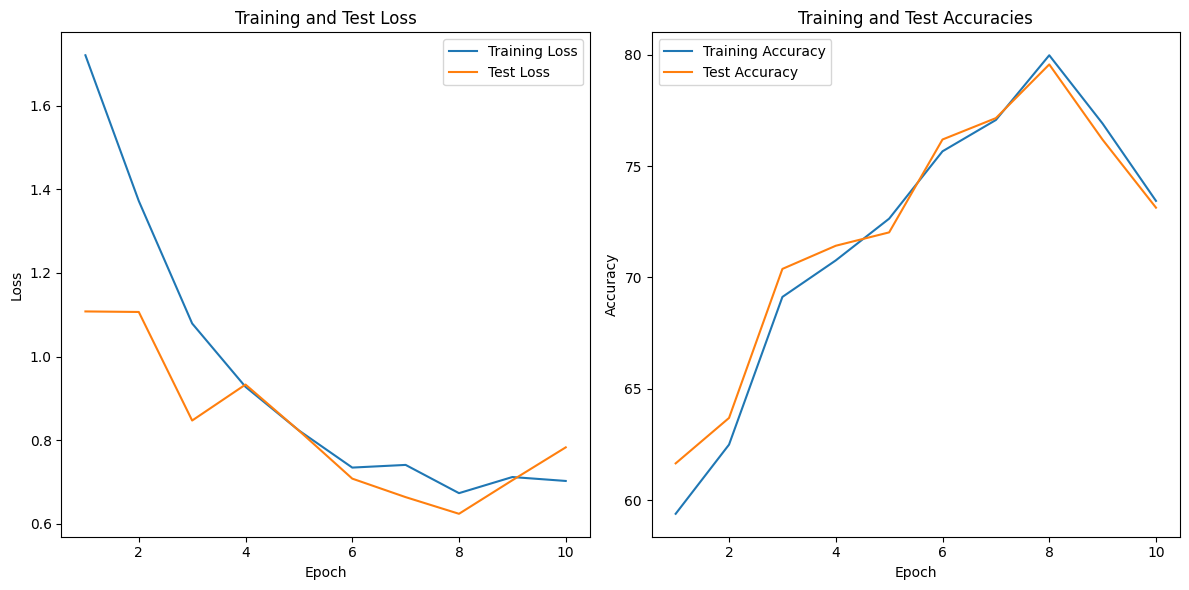

In [7]:
#Fine-tune ResNet18 model trained on ImageNet for CIFAR10 dataset.

# Load pretrained ResNet18 model
resnet = models.resnet18(pretrained=True)

# changing dropout and output layer
resnet.fc = nn.Sequential(nn.Dropout(dropout_prob), nn.Linear(in_features=512, out_features=10, bias=True))

# Move the model to gpu
resnet.to(device)

# Define loss function and optimizer
num_epochs = 10
learning_rate_resnet = 0.01
weight_decay = 5e-4 # L2 regularization
criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.SGD(resnet.parameters(), lr=learning_rate_resnet, momentum=0.9, weight_decay=weight_decay)
scheduler_resnet = optim.lr_scheduler.CosineAnnealingLR(optimizer_resnet, T_max=200) # T_max sets the iteration of the schedulers full-cycle to 200

print("Training ResNet18:\n============================================================================================================")
train_model(resnet, optimizer_resnet, scheduler_resnet, train_loader, test_loader, criterion, num_epochs)


ResNet18 Model:
 >> Loss (Training):     0.7664
 >> Accuracy (Training): 73.66%
 >> Loss (Testing):      0.7827
 >> Accuracy (Testing):  73.13%


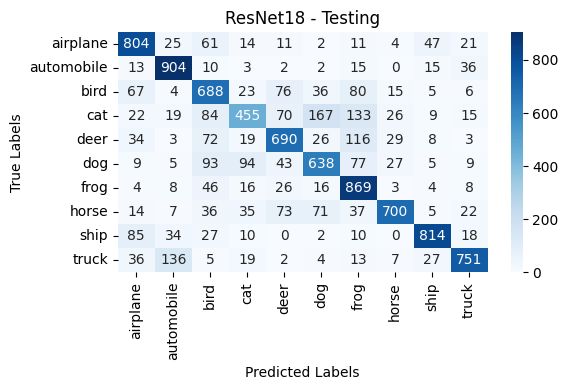

In [8]:
# Compare the accuarcay of simple CNN and ResNet18 model on the test set

# Evaluate the model
resnet_test_loss, resnet_test_accuracy = evaluate_model(resnet, test_loader, criterion, device)
resnet_train_loss, resnet_train_accuracy = evaluate_model(resnet, train_loader, criterion, device)

# Print performance of resnet
print("ResNet18 Model:")
print(f" >> Loss (Training):     {resnet_train_loss:.4f}")
print(f" >> Accuracy (Training): {resnet_train_accuracy:.2f}%")
print(f" >> Loss (Testing):      {resnet_test_loss:.4f}")
print(f" >> Accuracy (Testing):  {resnet_test_accuracy:.2f}%")

# Calculate confusion matrices forResNet18 models
resnet_test_confusion_matrix = calculate_confusion_matrix(resnet, test_loader, device)

# Plot CM for resnet
plt.figure(figsize=(6, 4))
sns.heatmap(resnet_test_confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("ResNet18 - Testing")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.tight_layout()
plt.show()